# Laboratorio 2: Deep Learning (Avance)
**CC3084 – Data Science | UVG | Semestre II 2026**

**Avance requerido (30 de julio de 2026):** al menos dos modelos LSTM, con tuneo de parámetros, para dos de las series construidas en el Laboratorio 1 (ingreso de viajeros internacionales a Guatemala).

**Series seleccionadas:** `Total` (serie obligatoria) y `Tipo_Turista` (categoría Tipo de viajero), usando exactamente la misma partición entrenamiento/prueba del Laboratorio 1 (corte cronológico 70/30: entrenamiento ene-2009 a mar-2021, prueba abr-2021 a jun-2026).


In [3]:
import warnings
warnings.filterwarnings('ignore')
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
TEAL = '#0B7285'

MESES = {'Ene':1,'Feb':2,'Mar':3,'Abr':4,'May':5,'Jun':6,
         'Jul':7,'Ago':8,'Sep':9,'Oct':10,'Nov':11,'Dic':12}


## 1. Carga de datos y reconstrucción de las series del Laboratorio 1

Se replica exactamente la misma carga, partición cronológica (70/30) y construcción de series mensuales usadas en el Laboratorio 1, para garantizar que los modelos LSTM se comparen con los mismos conjuntos de entrenamiento/prueba.


In [4]:
df = pd.read_excel('Base_Migracion_2009-2026jun.xlsx', sheet_name='Datos')
df['Mes_num'] = df['Mes'].map(MESES)
df['Fecha'] = pd.to_datetime(dict(year=df['Año'], month=df['Mes_num'], day=1))

fechas = sorted(df['Fecha'].unique())
n_train = int(len(fechas) * 0.7)
fecha_corte = fechas[n_train - 1]

train_df = df[df['Fecha'] <= fecha_corte].copy()
test_df  = df[df['Fecha'] >  fecha_corte].copy()

print(f'Entrenamiento: {train_df["Fecha"].nunique()} meses ({fechas[0]:%Y-%m} a {fecha_corte:%Y-%m})')
print(f'Prueba:        {test_df["Fecha"].nunique()} meses ({fechas[n_train]:%Y-%m} a {fechas[-1]:%Y-%m})')


Entrenamiento: 147 meses (2009-01 a 2021-03)
Prueba:        63 meses (2021-04 a 2026-06)


In [5]:
def monthly_series(data, full_index, filt=None):
    d = data if filt is None else data[filt]
    s = d.groupby('Fecha')['Viajero'].sum().sort_index()
    s = s.reindex(full_index, fill_value=0)
    s.index.freq = 'MS'
    return s

train_index = pd.date_range(train_df['Fecha'].min(), train_df['Fecha'].max(), freq='MS')
test_index  = pd.date_range(test_df['Fecha'].min(),  test_df['Fecha'].max(),  freq='MS')

series = {
    'Total':        monthly_series(train_df, train_index),
    'Tipo_Turista': monthly_series(train_df, train_index, train_df['Tipo de Viajero'] == 'Turista'),
}
series_test = {
    'Total':        monthly_series(test_df, test_index),
    'Tipo_Turista': monthly_series(test_df, test_index, test_df['Tipo de Viajero'] == 'Turista'),
}

for nombre in series:
    print(f"{nombre:15s} train: {len(series[nombre])} obs ({series[nombre].index.min():%Y-%m} a {series[nombre].index.max():%Y-%m})"
          f"  |  test: {len(series_test[nombre])} obs")


Total           train: 147 obs (2009-01 a 2021-03)  |  test: 63 obs
Tipo_Turista    train: 147 obs (2009-01 a 2021-03)  |  test: 63 obs


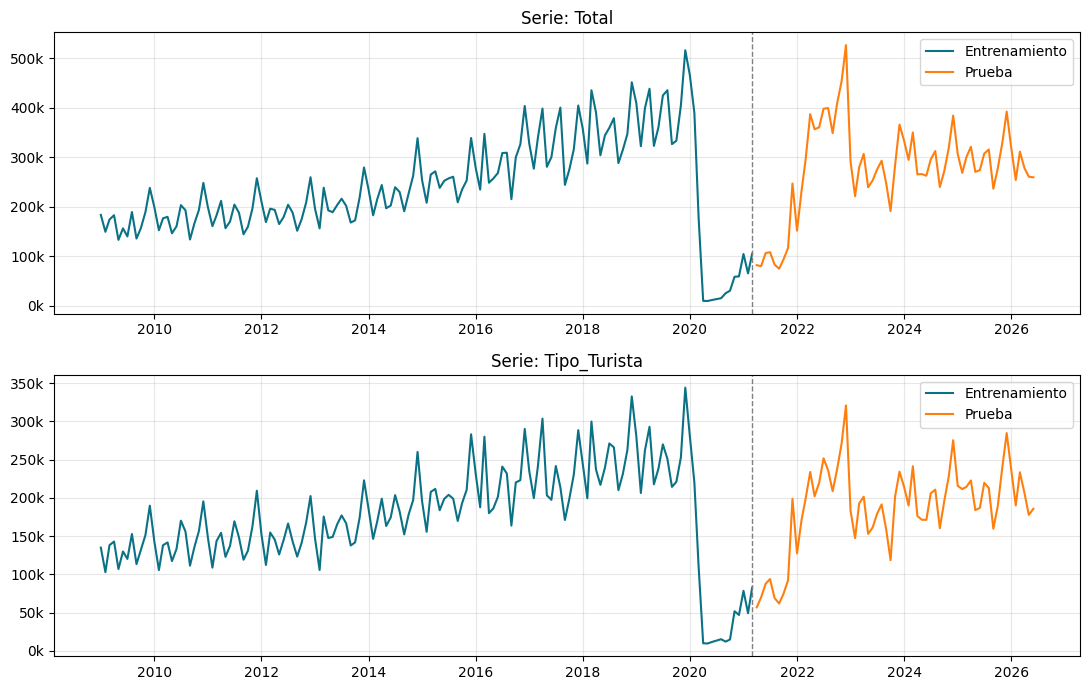

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)
for ax, nombre in zip(axes, series):
    ax.plot(series[nombre].index, series[nombre].values, label='Entrenamiento', color=TEAL)
    ax.plot(series_test[nombre].index, series_test[nombre].values, label='Prueba', color='tab:orange')
    ax.axvline(series[nombre].index[-1], color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'Serie: {nombre}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.legend()
plt.tight_layout()
plt.show()


## 2. Pipeline genérico para LSTM

Para series de tiempo univariadas se usa un enfoque de **ventana deslizante** (sliding window): se transforma la serie en pares (secuencia de `window` meses pasados → valor del mes siguiente). Se escala la serie con `MinMaxScaler` (ajustado **solo con el conjunto de entrenamiento**, para evitar fuga de información) y las predicciones sobre el conjunto de prueba se generan de forma **recursiva** (multi-step forecasting): cada predicción se realimenta como parte de la ventana para predecir el siguiente mes.


In [7]:
def crear_ventanas(arr, window):
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i+window])
        y.append(arr[i+window])
    return np.array(X), np.array(y)

class LSTMModel(nn.Module):
    def __init__(self, window, unidades, capas, dropout):
        super(LSTMModel, self).__init__()
        self.capas = capas
        
        if capas == 1:
            self.lstm = nn.LSTM(input_size=1, hidden_size=unidades, batch_first=True)
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(unidades, 1)
        else:
            self.lstm1 = nn.LSTM(input_size=1, hidden_size=unidades, batch_first=True)
            self.dropout1 = nn.Dropout(dropout)
            
            unidades_capa2 = max(unidades // 2, 8)
            self.lstm2 = nn.LSTM(input_size=unidades, hidden_size=unidades_capa2, batch_first=True)
            self.dropout2 = nn.Dropout(dropout)
            self.fc = nn.Linear(unidades_capa2, 1)

    def forward(self, x):
        if self.capas == 1:
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            out = self.fc(out)
        else:
            out, _ = self.lstm1(x)
            out = self.dropout1(out)
            out, _ = self.lstm2(out)
            out = self.dropout2(out[:, -1, :])
            out = self.fc(out)
        return out

def entrenar_y_evaluar(serie_train, serie_test, config, verbose=0):
    """Entrena una config de LSTM con validación interna (últimos 15% del train)
    y devuelve el modelo, el scaler, el forecast recursivo sobre el conjunto de
    prueba y las métricas (val y test)."""
    window = config['window']
    values = serie_train.values.reshape(-1, 1).astype(float)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(values).flatten()

    X, y = crear_ventanas(scaled, window)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    n_val = max(int(len(X) * 0.15), 6)
    X_tr, y_tr = X[:-n_val], y[:-n_val]
    X_val, y_val = X[-n_val:], y[-n_val:]

    # Convert to PyTorch tensors
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(-1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)

    # Initialize model, loss and optimizer
    torch.manual_seed(42)
    model = LSTMModel(window, config['unidades'], config['capas'], config['dropout'])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])

    # Training loop parameters
    dataset_size = X_tr_t.size(0)
    batch_size = config.get('batch_size', 8)
    epochs = config.get('epochs', 150)
    patience = 15
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    history_loss = []
    history_val_loss = []

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(dataset_size)
        epoch_loss = 0.0
        batches = 0
        
        for i in range(0, dataset_size, batch_size):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X_tr_t[indices], y_tr_t[indices]
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batches += 1
            
        avg_train_loss = epoch_loss / batches
        history_loss.append(avg_train_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            avg_val_loss = criterion(val_outputs, y_val_t).item()
            
        history_val_loss.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            import copy
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    # Restore best weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Validation predictions for MAE
    model.eval()
    with torch.no_grad():
        val_pred_scaled = model(X_val_t).cpu().numpy().flatten()
        
    val_mae = mean_absolute_error(
        scaler.inverse_transform(y_val_t.cpu().numpy().reshape(-1,1)),
        scaler.inverse_transform(val_pred_scaled.reshape(-1,1))
    )

    # Recursive forecast on test set
    h = len(serie_test)
    ventana = scaled[-window:].tolist()
    preds_scaled = []
    
    with torch.no_grad():
        for _ in range(h):
            x_in = torch.tensor(ventana[-window:], dtype=torch.float32).view(1, window, 1)
            p = model(x_in).item()
            preds_scaled.append(p)
            ventana.append(p)

    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1,1)).flatten()
    preds = np.clip(preds, 0, None)

    test_mae = mean_absolute_error(serie_test.values, preds)
    test_rmse = np.sqrt(mean_squared_error(serie_test.values, preds))

    return {
        'config': config, 'model': model, 'scaler': scaler,
        'val_mae_scaled': val_mae, 'test_mae': test_mae, 'test_rmse': test_rmse,
        'forecast': pd.Series(preds, index=serie_test.index),
        'history': {'loss': history_loss, 'val_loss': history_val_loss}
    }


## 3. Ejercicio 1.1 - 1.2: Modelos LSTM con tuneo de parámetros (2 configuraciones por serie)

Se prueban varias combinaciones de hiperparámetros (tamaño de ventana, número de unidades LSTM, número de capas, dropout y tasa de aprendizaje) para cada serie, y se conserva **la mejor por MAE de validación** de entre dos arquitecturas representativas:

- **Config A — LSTM simple:** 1 capa LSTM, ventana corta, pocas unidades (modelo liviano).
- **Config B — LSTM más profundo:** 2 capas LSTM apiladas, ventana más larga (captura estacionalidad anual con ventana=12), más unidades y dropout más alto (regularización).

Sobre cada una se hace además una búsqueda pequeña (tuneo) variando unidades/dropout/lr, y se conserva la mejor variante de cada familia.


In [8]:
grid_configs = {
    'A_simple': [
        {'window': 6,  'unidades': 16, 'capas': 1, 'dropout': 0.1, 'lr': 0.01,  'epochs': 150, 'batch_size': 8},
        {'window': 6,  'unidades': 32, 'capas': 1, 'dropout': 0.2, 'lr': 0.005, 'epochs': 150, 'batch_size': 8},
        {'window': 3,  'unidades': 16, 'capas': 1, 'dropout': 0.1, 'lr': 0.01,  'epochs': 150, 'batch_size': 8},
    ],
    'B_profundo': [
        {'window': 12, 'unidades': 64, 'capas': 2, 'dropout': 0.2, 'lr': 0.005, 'epochs': 200, 'batch_size': 8},
        {'window': 12, 'unidades': 32, 'capas': 2, 'dropout': 0.3, 'lr': 0.01,  'epochs': 200, 'batch_size': 8},
        {'window': 24, 'unidades': 64, 'capas': 2, 'dropout': 0.3, 'lr': 0.005, 'epochs': 200, 'batch_size': 8},
    ],
}

resultados_lstm = {}  # resultados_lstm[serie][familia] = mejor resultado de la familia

for nombre_serie in series:
    resultados_lstm[nombre_serie] = {}
    print(f'\n========== Serie: {nombre_serie} ==========')
    for familia, configs in grid_configs.items():
        print(f'  -- Tuneo familia {familia} --')
        mejor = None
        for cfg in configs:
            r = entrenar_y_evaluar(series[nombre_serie], series_test[nombre_serie], cfg)
            print(f"    window={cfg['window']:>2} unidades={cfg['unidades']:>3} capas={cfg['capas']} "
                  f"dropout={cfg['dropout']} lr={cfg['lr']:<6} -> val_MAE={r['val_mae_scaled']:.1f}  test_MAE={r['test_mae']:.1f}")
            if mejor is None or r['val_mae_scaled'] < mejor['val_mae_scaled']:
                mejor = r
        resultados_lstm[nombre_serie][familia] = mejor
        print(f"  >>> Mejor de {familia}: window={mejor['config']['window']}, unidades={mejor['config']['unidades']}, "
              f"capas={mejor['config']['capas']}, dropout={mejor['config']['dropout']}, lr={mejor['config']['lr']} "
              f"(val_MAE={mejor['val_mae_scaled']:.1f})")



========== Serie: Total ==========
  -- Tuneo familia A_simple --
    window= 6 unidades= 16 capas=1 dropout=0.1 lr=0.01   -> val_MAE=90872.9  test_MAE=124014.2
    window= 6 unidades= 32 capas=1 dropout=0.2 lr=0.005  -> val_MAE=94521.5  test_MAE=147778.9
    window= 3 unidades= 16 capas=1 dropout=0.1 lr=0.01   -> val_MAE=77514.1  test_MAE=135960.8
  >>> Mejor de A_simple: window=3, unidades=16, capas=1, dropout=0.1, lr=0.01 (val_MAE=77514.1)
  -- Tuneo familia B_profundo --
    window=12 unidades= 64 capas=2 dropout=0.2 lr=0.005  -> val_MAE=134132.1  test_MAE=115314.7
    window=12 unidades= 32 capas=2 dropout=0.3 lr=0.01   -> val_MAE=165199.8  test_MAE=97005.9
    window=24 unidades= 64 capas=2 dropout=0.3 lr=0.005  -> val_MAE=115369.7  test_MAE=220801.2
  >>> Mejor de B_profundo: window=24, unidades=64, capas=2, dropout=0.3, lr=0.005 (val_MAE=115369.7)

========== Serie: Tipo_Turista ==========
  -- Tuneo familia A_simple --
    window= 6 unidades= 16 capas=1 dropout=0.1 lr=0.01   